VISUALS

QUESTION 1:
The Elite Five: Which are the top 5 universities currently leading the National Rank?

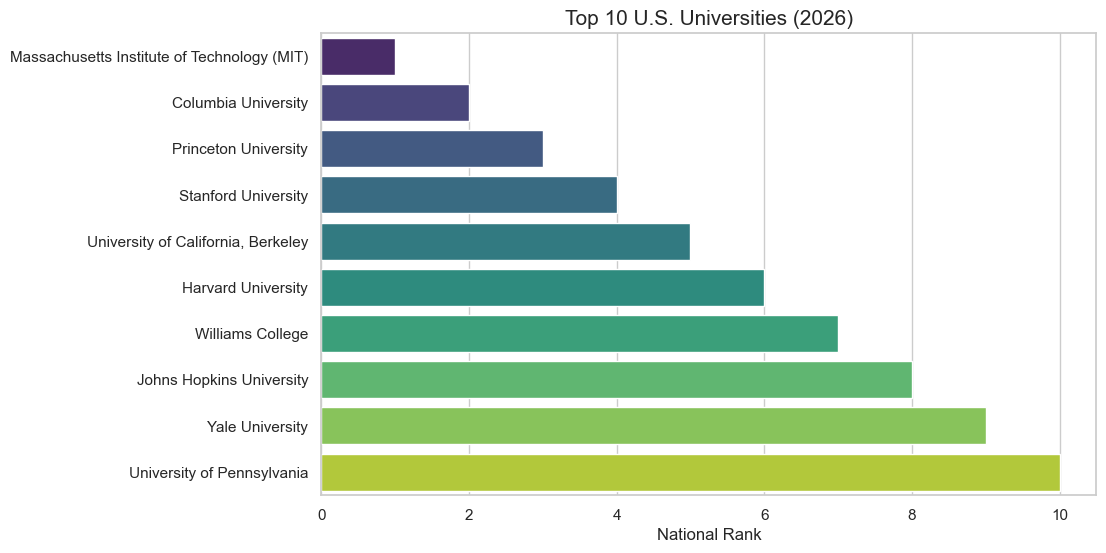

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

# 1. Load data from your new SQL database
engine = create_engine('sqlite:///uni_data.db')
df = pd.read_sql('SELECT * FROM universities', con=engine)

# Set the visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# --- VISUAL 1: Top 10 Universities by National Rank ---
plt.figure(figsize=(10, 6))
top_10 = df.nsmallest(10, 'national_rank')

# Fix: Added 'hue', set 'legend=False', and 'palette'
sns.barplot(
    data=top_10, 
    x='national_rank', 
    y='university_name', 
    hue='university_name', 
    palette='viridis', 
    legend=False
)

plt.title('Top 10 U.S. Universities (2026)', fontsize=15)
plt.xlabel('National Rank')
plt.ylabel('')
plt.show()

QUESTION 2:
Public vs. Private Research: What is the average Research Impact Score for Public vs. Private institutions? (Great for a Bar Chart)

C:\Users\pablo\AppData\Local\Temp\ipykernel_17784\641364846.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='institution_type', y='research_impact_score', palette='Set2')


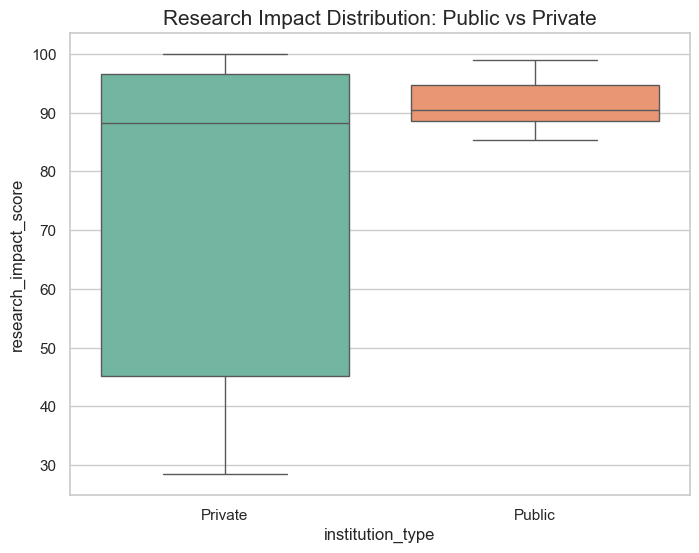

In [2]:
# --- VISUAL 2: Research Impact: Public vs Private ---
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='institution_type', y='research_impact_score', palette='Set2')
plt.title('Research Impact Distribution: Public vs Private', fontsize=15)
plt.show()

QUESTION 3:
The State Leaderboard: Which states have the highest number of universities in the Top 50? (Identifies "Education Hubs").

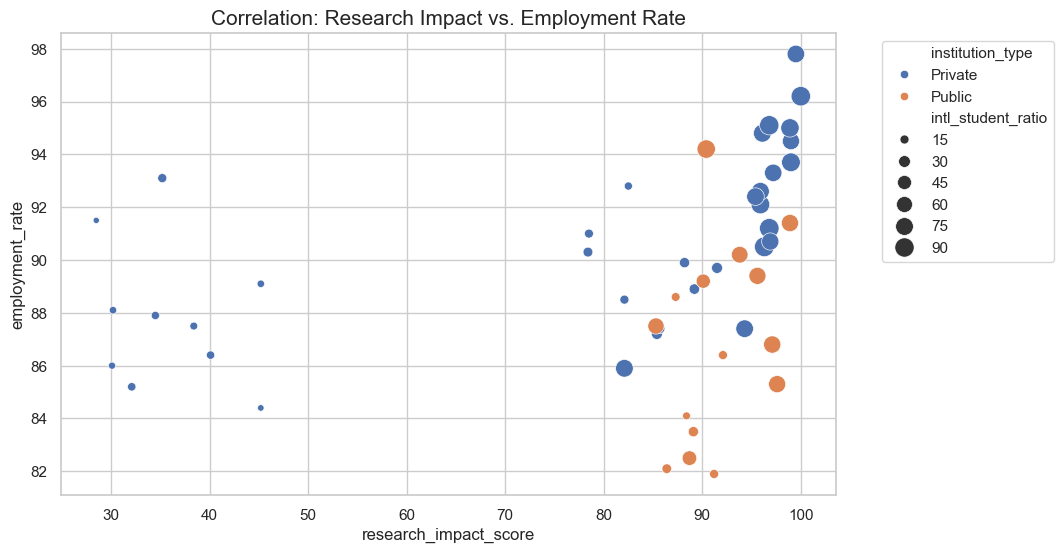

In [3]:
# --- VISUAL 3: Research Impact vs. Employment Rate ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='research_impact_score', y='employment_rate', 
                hue='institution_type', size='intl_student_ratio', sizes=(20, 200))
plt.title('Correlation: Research Impact vs. Employment Rate', fontsize=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

📈 Visual for Q7: Performance by Century (The "Era" Analysis)
This shows if older universities actually perform better. A Point Plot or Bar Plot works best here.

C:\Users\pablo\AppData\Local\Temp\ipykernel_17784\4048542107.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='era', y='research_impact_score', order=era_order, palette='magma', capsize=.1)


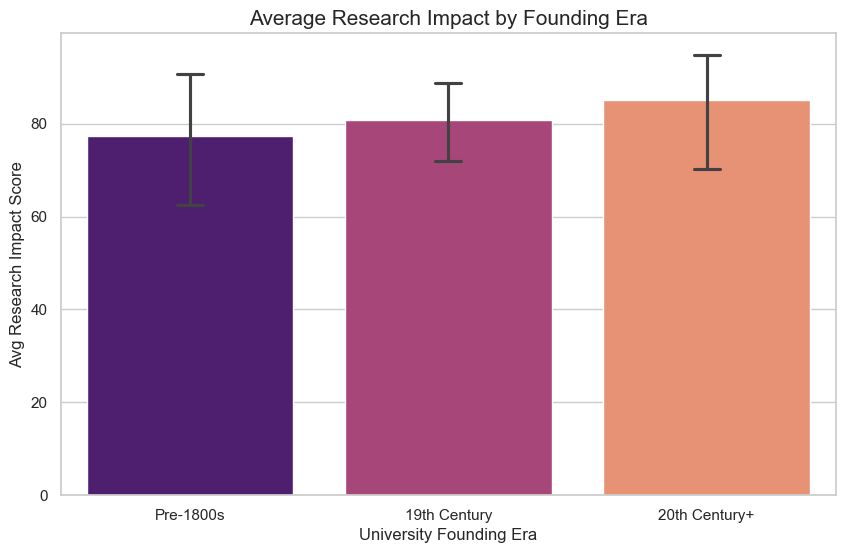

In [4]:
# Create the 'Era' column for the visual
df['era'] = df['founded_year'].apply(lambda x: 'Pre-1800s' if x < 1800 else ('19th Century' if x < 1900 else '20th Century+'))

# Sort the eras so they appear chronologically on the chart
era_order = ['Pre-1800s', '19th Century', '20th Century+']

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='era', y='research_impact_score', order=era_order, palette='magma', capsize=.1)
plt.title('Average Research Impact by Founding Era', fontsize=15)
plt.ylabel('Avg Research Impact Score')
plt.xlabel('University Founding Era')
plt.show()

🍰 Visual for Q8: Public vs. Private Split (%)
A Pie Chart is the classic choice here to show market share in the Top 50.

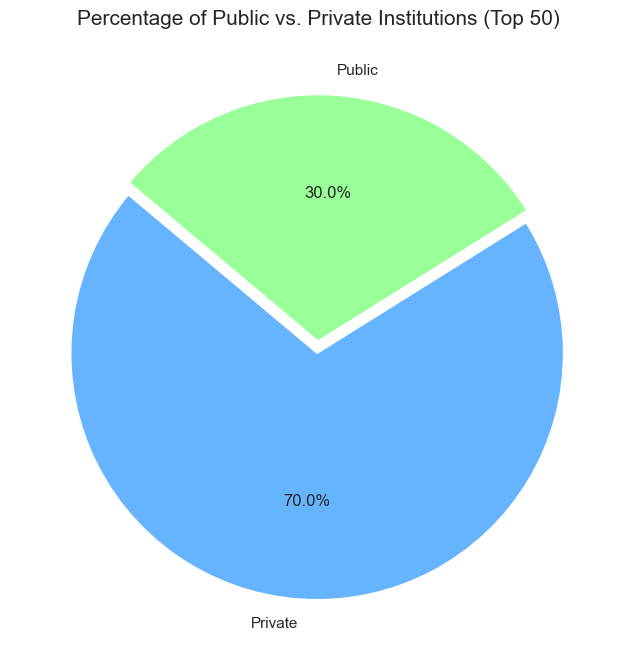

In [5]:
# Get the counts
type_counts = df['institution_type'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=['#66b3ff','#99ff99'], explode=(0.05, 0))
plt.title('Percentage of Public vs. Private Institutions (Top 50)', fontsize=15)
plt.show()